In [2]:
#Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import numpy as np
import os
import h5py

current_dir = os.getcwd()

#Loading GT and SUB Data
try:
    #Output/GT_h5/groundtruth.h5
    folder_dir = "output/GT_h5"
    h5_file_path = os.path.join(current_dir, "output", "GT_h5", "groundtruth.h5")
    gt_data  = pd.read_hdf(h5_file_path, "/data")
    print("Voltage Data Loading done!")
    gt_spikes = pd.read_hdf(h5_file_path,"/spikes_raw")
    print("Spikes Data Loading done!")

    sub_data = gt_data
    sub_spikes = gt_spikes

    #Common to both GT and SUB
    cfg  = pd.read_hdf(h5_file_path, "/network_config")
    print("Network configuration Loading done!")
    tmap = pd.read_hdf(h5_file_path, "/trial_map")
    print("Trial Map Loading done!")

    import json
    with open("output/GT/network_config.json", "r") as f:
        net_config = json.load(f)
    truth_table = net_config["truth_table"]

    patterns = tmap["case"].unique().tolist()

except Exception as e:
    print(f"Data laoding failed as {e}")


Voltage Data Loading done!
Spikes Data Loading done!
Network configuration Loading done!
Trial Map Loading done!


In [3]:
try:
    # verify GT and SUB have same number of trials
    assert len(gt_data["trial_id"].unique()) == len(sub_data["trial_id"].unique())

    # verify pattern distribution is identical
    assert (gt_data.groupby("case").size() == sub_data.groupby("case").size()).all()

except Exception as e:
    print(e)

In [4]:
#Helper Functions
def get_neurons(cfg, role=None, input_channel=None):
    #     role="output"                 - ["E"]
    #     role="input"                  - ["PyrIn_A","PyrIn_B1","PyrIn_B2"]
    #     role=["input","interneuron",
    #           "intermediate","output"]- all 8 active neurons
    #     role="all"                    - all 35 labels
    #     input_channel=2               - ["PyrIn_B1","PyrIn_B2"]
    result = cfg
    if role!= None and role!= "all":
        if isinstance(role, list):
            result = result[result["role"].isin(role)]
        else:
            result = result[result["role"] == role]

    if input_channel!= None:
        result = result[result["input_channel"] == input_channel]

    return result["label"].tolist()
        
def get_spiking_neurons(cfg, data, label = None):
    #     checks _spike cols in data at runtime
    #     returns labels where spike col sum > 0
    spiking = []

    if label == None:
        for _ in cfg["label"]:
            if data[f"{_}_spike"].sum()>0:
                spiking.append(_)
    else:
        if data[label].sum() > 0:
            spiking.append(label)
       
    return spiking
        
def get_spike_cols(cfg, data, role =None):
   #     calls get_spiking_neurons()
   #     returns ["{label}_spike", ...] for spiking neurons
   columns = []
   
   if role == None:
        for label in get_spiking_neurons(cfg,data):
            columns.append(f"{label}_spike")
    
   else:
        for label in get_neurons(cfg, role=role):
            columns.append(f"{label}_spike")
    
   return columns

def get_vm_cols(cfg, scope="all"):
    #     scope="all"    - all 35 _vm column names
    #     scope="active" - 8 active neurons _vm column names
    roles = []
    if(scope == "active"):
        for _,row in cfg.iterrows():
            if row["role"] != "extended_network":
                roles.append(f"{row['label']}_vm")
    else:
        for _,row in cfg.iterrows():
            roles.append(f"{row['label']}_vm")
    return roles

def get_trial(data, trial_id):
    return data[data["trial_id"] == trial_id]

def get_trials_by_pattern(data, pattern):
    #     returns list of DataFrames where case == pattern
    #     10 DataFrames per pattern (one per rep)
    result = []
    unique = data["rep"].unique()
    for u in unique:
        filtered = data[(data["case"] == pattern) & (data["rep"] == u)]
        result.append(filtered)

    return result

def load_metadata(h5_path):
    #     reads /metadata attrs via h5py
    #     returns plain dict:
    #       {"fs_hz": 1000.0, "t_total_ms": 4000.0, "n_trials": 40,
    #        "trial_len_ms": 100.0, "n_neurons_total": 35, "n_neurons_spiking": 8}
    with h5py.File(h5_path,"r") as f:
        metadata = dict(f["/metadata"].attrs)
    
    return metadata

In [5]:
#Behavioural Metrics
#This metric needs the output neuron

# Get output neuron spike column and trial length from metadata
role_behavioural = "output"
label = get_spike_cols(cfg, gt_data, role=role_behavioural)[0]
meta = load_metadata(h5_file_path)
trial_len = meta["trial_len_ms"]

def compute_confusion_matrix(data,pattern):
    """
    For a given pattern, loops over all 10 repetitions and checks
    whether E fired within the trial window. Classifies each trial
    as TP, FN, TN or FP based on the truth table.
    """
    trials = get_trials_by_pattern(data,pattern)
    TP, FN, TN, FP = 0, 0, 0, 0
    for t in trials:
        #print(t["t_in_trial"])
        window = t[t["t_in_trial"] <= trial_len]
        fired = window[label].sum() > 0
        want = truth_table[f"XOR_{pattern}"]["expected_output"]
        have = 1 if fired else 0

        if want == 1 and have == 1:
            TP += 1
        elif want == 1 and have == 0:
            FN += 1
        elif want == 0 and have == 0:
            TN += 1
        else:
            FP += 1

    return TP,FN,TN,FP
        
def all_patterns(data,patterns):
    """
    Runs compute_confusion_matrix() for all 4 XOR patterns.
    Patterns derived from tmap — not hardcoded.
    Returns a DataFrame with TP/FN/TN/FP and derived metrics per pattern.
    """     
    rows = []
    for p in patterns:
        tp,fn,tn,fp = compute_confusion_matrix(data,p)
        den = tp + fn + tn + fp
        rows.append({
            "Pattern": p,
            "TP": tp, "FN": fn, "TN": tn, "FP": fp,
            "Accuracy": (tp + tn) / den if den else 0.0,
            "Sensitivity": tp / (tp + fn) if (tp + fn) else 0.0,
            "Specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        })

    return pd.DataFrame(rows)

print(pd.DataFrame(truth_table))
gt_results = all_patterns(gt_data,patterns)
sub_results = all_patterns(sub_data,patterns)
print("Ground Truth:")
print(gt_results.to_string(index=False))
print("\nSubmission:")
print(sub_results.to_string(index=False))


                 XOR_00  XOR_01  XOR_10  XOR_11
input_A               0       0       1       1
input_B               0       1       0       1
expected_output       0       1       1       0
Ground Truth:
Pattern  TP  FN  TN  FP  Accuracy  Sensitivity  Specificity
     00   0   0  10   0       1.0          0.0          1.0
     11   0   0  10   0       1.0          0.0          1.0
     01  10   0   0   0       1.0          1.0          0.0
     10  10   0   0   0       1.0          1.0          0.0

Submission:
Pattern  TP  FN  TN  FP  Accuracy  Sensitivity  Specificity
     00   0   0  10   0       1.0          0.0          1.0
     11   0   0  10   0       1.0          0.0          1.0
     01  10   0   0   0       1.0          1.0          0.0
     10  10   0   0   0       1.0          1.0          0.0


In [6]:
#Membrane potential (stitched traces, median +- IQR)



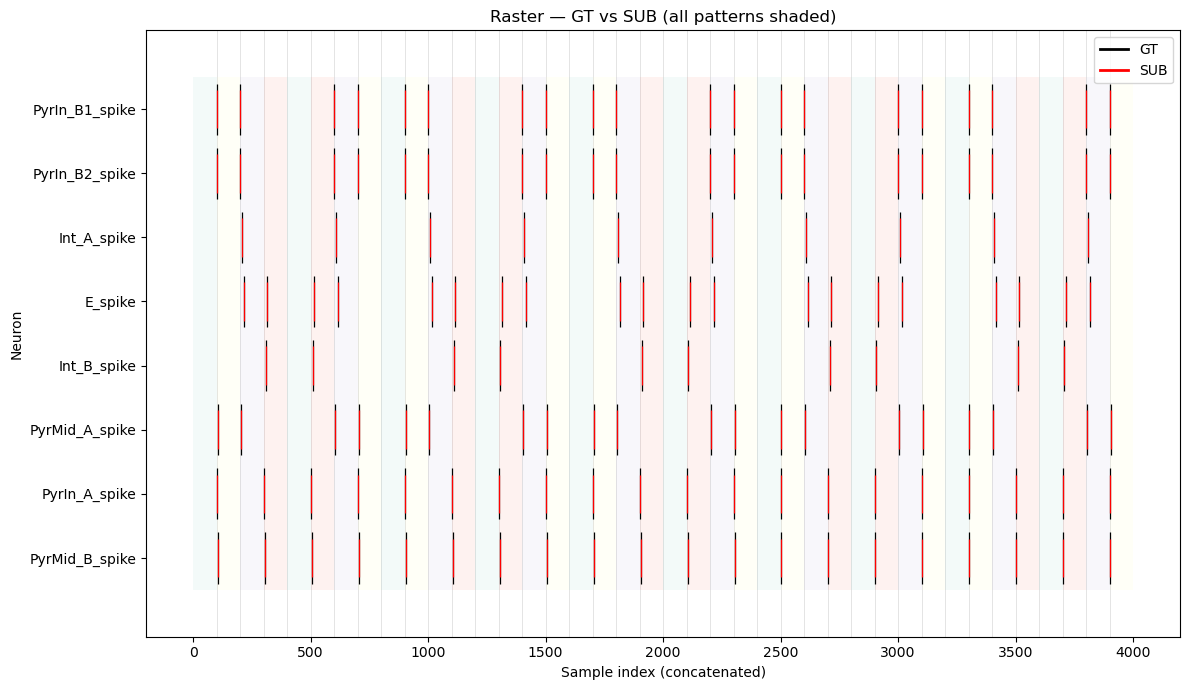

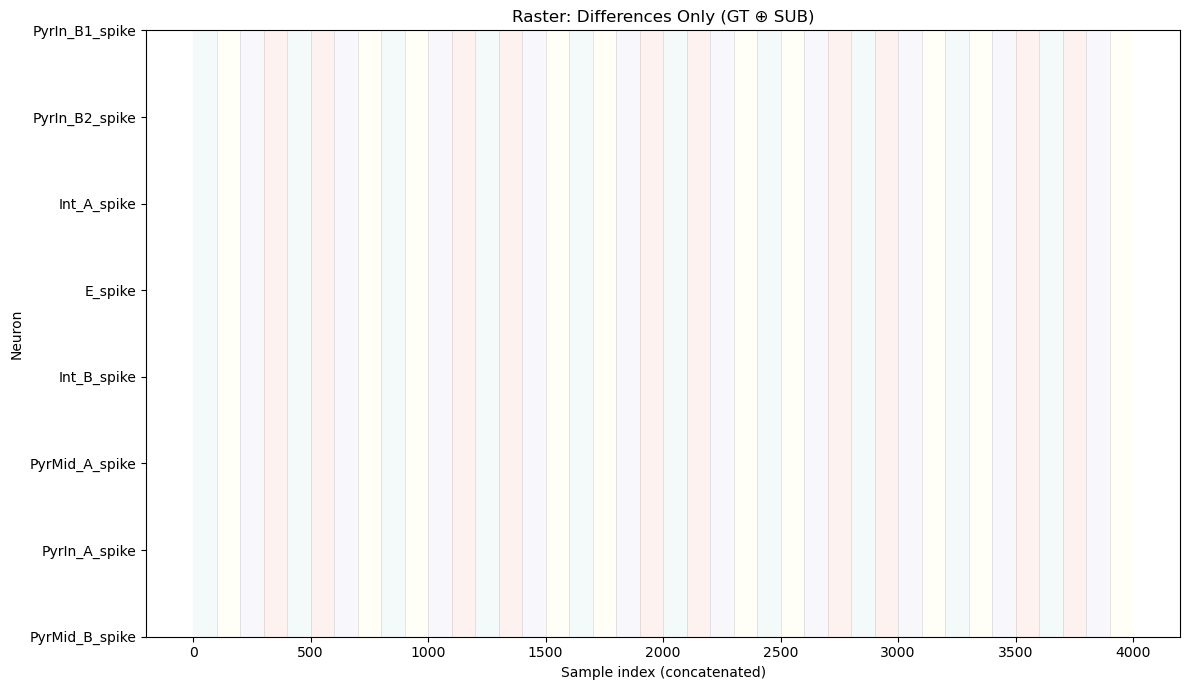


Jaccard similarity per neuron:
  PyrMid_B_spike     1.000
  PyrIn_A_spike      1.000
  PyrMid_A_spike     1.000
  Int_B_spike        1.000
  E_spike            1.000
  Int_A_spike        1.000
  PyrIn_B2_spike     1.000
  PyrIn_B1_spike     1.000
Mean Jaccard: 1.000

Difference counts (GT⊕SUB) per neuron:
  PyrMid_B_spike     0
  PyrIn_A_spike      0
  PyrMid_A_spike     0
  Int_B_spike        0
  E_spike            0
  Int_A_spike        0
  PyrIn_B2_spike     0
  PyrIn_B1_spike     0

Mean Jaccard by pattern:
  pattern 00: 1.000
  pattern 11: 1.000
  pattern 01: 1.000
  pattern 10: 1.000


In [21]:
#Raster Plot Visualization - Compare GT vs SUB spike patterns
gt_spike_cols  = set(get_spike_cols(cfg, gt_data))
sub_spike_cols = set(get_spike_cols(cfg, sub_data))
spike_cols = list(gt_spike_cols | sub_spike_cols)
trial_len  = int(meta["trial_len_ms"])             
patterns   = tmap["case"].unique().tolist()        

gt  = gt_data.copy()
sub = sub_data.copy()

FILTER_PATTERN = None

# Align lengths
n_rows = min(len(gt), len(sub))
gt = gt.iloc[:n_rows].reset_index(drop=True)
sub = sub.iloc[:n_rows].reset_index(drop=True)

# Extract spike times
gt_times = [np.where(gt[c].to_numpy(dtype=int) == 1)[0] for c in spike_cols]
sb_times = [np.where(sub[c].to_numpy(dtype=int) == 1)[0] for c in spike_cols]
diff_times = [np.setxor1d(g, s) for g, s in zip(gt_times, sb_times)]

def add_pattern_bands(ax, df, trial_len=100, alpha=0.10):
    """Add colored background bands to indicate input patterns."""
    import matplotlib.cm as cm
    unique_patterns = tmap["case"].unique()
    color_list = cm.Set3.colors[:len(unique_patterns)]
    colors = dict(zip(unique_patterns, [f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}" for r,g,b in color_list]))
    last_tid = int(df["trial_id"].iloc[-1])
    for tid in range(last_tid + 1):
        block = df[df["trial_id"] == tid]
        if block.empty:
            continue
        start = int(block.index.min())
        pat = str(block["case"].iloc[0])
        rect = Rectangle((start, -0.5), trial_len, len(spike_cols),
                        color=colors.get(pat, "#dddddd"), alpha=alpha, lw=0)
        ax.add_patch(rect)

# Figure 1: Overlay raster (GT and SUB)
fig, ax = plt.subplots(figsize=(12, 7))

if FILTER_PATTERN is None:
    add_pattern_bands(ax, gt, trial_len=trial_len, alpha=0.10)

ax.eventplot(gt_times, orientation="horizontal", linelengths=0.8, linewidths=0.9, colors="black")
ax.eventplot(sb_times, orientation="horizontal", linelengths=0.6, linewidths=0.9, colors="red")

ax.set_yticks(np.arange(len(spike_cols)))
ax.set_yticklabels(spike_cols)
ax.set_xlabel("Sample index (concatenated)")
ax.set_ylabel("Neuron")
ttl = "Raster — GT vs SUB" + (f" (pattern {FILTER_PATTERN})" if FILTER_PATTERN else " (all patterns shaded)")
ax.set_title(ttl)

# Legend
handles = [Line2D([0],[0], color="black", lw=2, label="GT"),
           Line2D([0],[0], color="red", lw=2, label="SUB")]
ax.legend(handles=handles, loc="upper right")

# Trial separators
total_trials = int(np.ceil(n_rows / trial_len))
for k in range(1, total_trials):
    ax.axvline(k * trial_len, color="0.85", lw=0.5, zorder=0)

plt.tight_layout()
plt.show()

# Figure 2: Differences-only raster
fig, ax = plt.subplots(figsize=(12, 7))

if FILTER_PATTERN is None:
    add_pattern_bands(ax, gt, trial_len=trial_len, alpha=0.10)

ax.eventplot(diff_times, orientation="horizontal", linelengths=0.8, linewidths=0.9, colors="purple")
ax.set_yticks(np.arange(len(spike_cols)))
ax.set_yticklabels(spike_cols)
ax.set_xlabel("Sample index (concatenated)")
ax.set_ylabel("Neuron")
ax.set_title("Raster: Differences Only (GT ⊕ SUB)" + (f" (pattern {FILTER_PATTERN})" if FILTER_PATTERN else ""))

for k in range(1, total_trials):
    ax.axvline(k * trial_len, color="0.85", lw=0.5, zorder=0)

plt.tight_layout()
plt.show()

# Numeric insights
def jaccard(a_idx, b_idx):
    """Compute Jaccard similarity between two spike index arrays."""
    if len(a_idx) == 0 and len(b_idx) == 0:
        return 1.0
    if len(a_idx) == 0 or len(b_idx) == 0:
        return 0.0
    inter = len(np.intersect1d(a_idx, b_idx))
    uni = len(np.union1d(a_idx, b_idx))
    return inter / uni if uni > 0 else 0.0

# Per-neuron Jaccard similarity
J = np.array([jaccard(g, s) for g, s in zip(gt_times, sb_times)], float)
mismatch_counts = {name: int(len(d)) for name, d in zip(spike_cols, diff_times)}
meanJ = float(np.nanmean(J)) if np.isfinite(J).any() else float("nan")

print("\nJaccard similarity per neuron:")
for name, val in zip(spike_cols, J):
    print(f"  {name:<18} {('%.3f'%val) if np.isfinite(val) else 'NA'}")
print(f"Mean Jaccard: {meanJ:.3f}" if np.isfinite(meanJ) else "Mean Jaccard: NA")

print("\nDifference counts (GT⊕SUB) per neuron:")
for k, v in mismatch_counts.items():
    print(f"  {k:<18} {v}")

# Per-pattern Jaccard (when showing all patterns)
if FILTER_PATTERN is None:
    pats = ["00","01","10","11"]
    per_pat = {}
    for p in pats:
        gtp = gt[gt["case"]==p]
        subp = sub[sub["case"]==p]
        n = min(len(gtp), len(subp))
        gtp = gtp.iloc[:n]
        subp = subp.iloc[:n]
        gts = [np.where(gtp[c].to_numpy(int)==1)[0] for c in spike_cols]
        sbs = [np.where(subp[c].to_numpy(int)==1)[0] for c in spike_cols]
        Jp = np.array([jaccard(a,b) for a,b in zip(gts,sbs)], float)
        per_pat[p] = float(np.nanmean(Jp))

    print("\nMean Jaccard by pattern:") 
    for p in patterns:
        print(f"  pattern {p}: {per_pat[p]:.3f}")       

GT Model

      neuron pattern        cv  fano                                                              isi
0          E      00       NaN   NaN                                                               []
1          E      11       NaN   NaN                                                               []
2          E      01  0.000000   0.0  [400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0]
3          E      10  0.528920   0.0  [199.0, 601.0, 199.0, 601.0, 199.0, 601.0, 199.0, 601.0, 199.0]
4      Int_A      00       NaN   NaN                                                               []
5      Int_A      11       NaN   NaN                                                               []
6      Int_A      01  0.000000   0.0  [400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0]
7      Int_A      10       NaN   NaN                                                               []
8      Int_B      00       NaN   NaN                                    

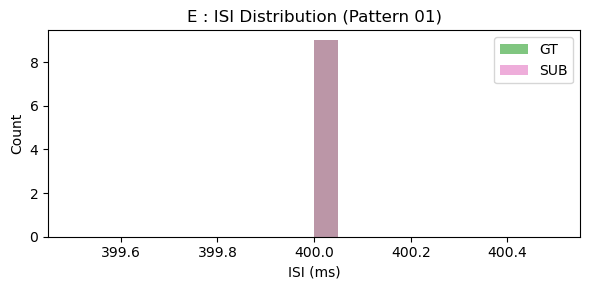


Neuron: E | Pattern: 10
  GT  - CV: 0.5289 | Fano: 0.0
  SUB - CV: 0.5289 | Fano: 0.0
  Wasserstein: 0.0000


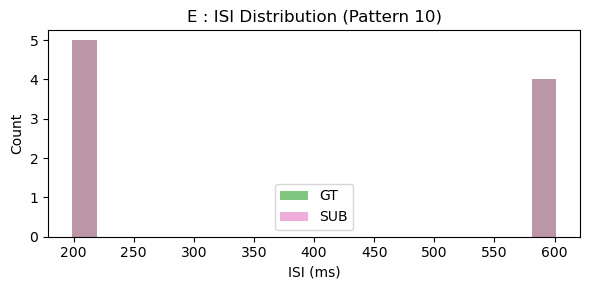


Neuron: Int_A | Pattern: 01
  GT  - CV: 0.0000 | Fano: 0.0
  SUB - CV: 0.0000 | Fano: 0.0
  Wasserstein: 0.0000


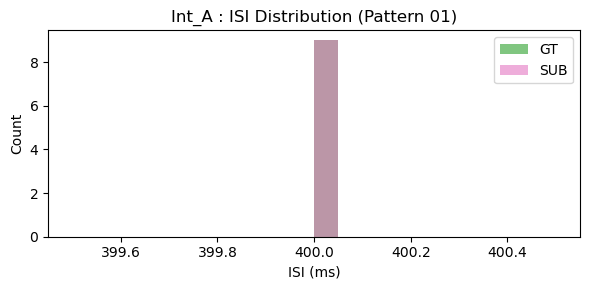


Neuron: Int_B | Pattern: 10
  GT  - CV: 0.5289 | Fano: 0.0
  SUB - CV: 0.5289 | Fano: 0.0
  Wasserstein: 0.0000


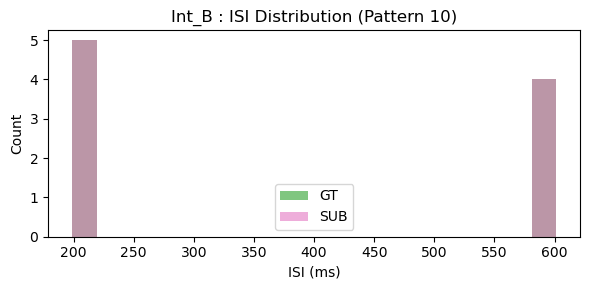


Neuron: PyrMid_A | Pattern: 11
  GT  - CV: 0.4730 | Fano: 0.0
  SUB - CV: 0.4730 | Fano: 0.0
  Wasserstein: 0.0000


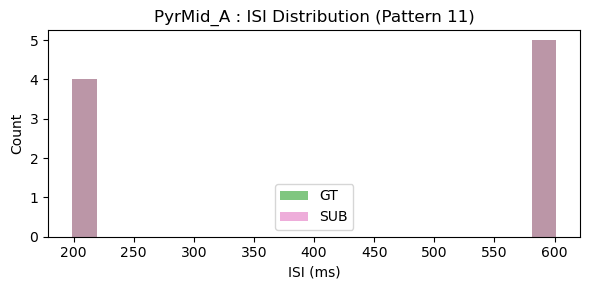


Neuron: PyrMid_A | Pattern: 01
  GT  - CV: 0.0025 | Fano: 0.0
  SUB - CV: 0.0025 | Fano: 0.0
  Wasserstein: 0.0000


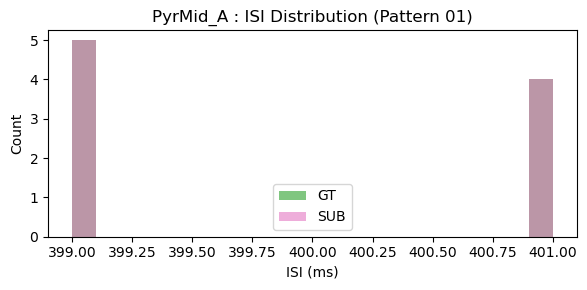


Neuron: PyrMid_B | Pattern: 11
  GT  - CV: 0.4708 | Fano: 0.0
  SUB - CV: 0.4708 | Fano: 0.0
  Wasserstein: 0.0000


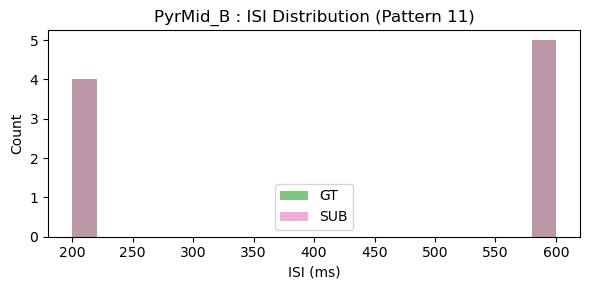


Neuron: PyrMid_B | Pattern: 10
  GT  - CV: 0.5261 | Fano: 0.0
  SUB - CV: 0.5261 | Fano: 0.0
  Wasserstein: 0.0000


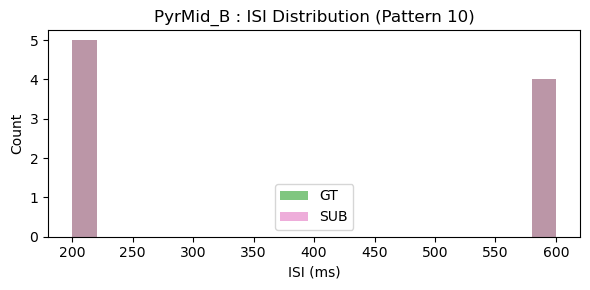


Neuron: PyrIn_B1 | Pattern: 11
  GT  - CV: 0.4708 | Fano: 0.0
  SUB - CV: 0.4708 | Fano: 0.0
  Wasserstein: 0.0000


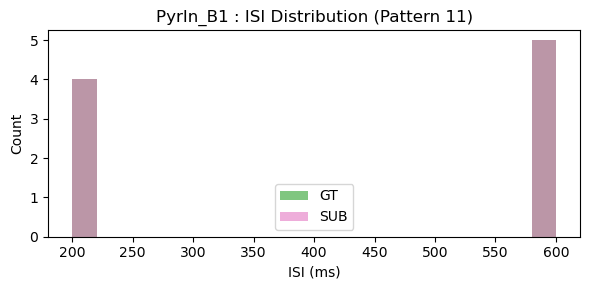


Neuron: PyrIn_B1 | Pattern: 01
  GT  - CV: 0.0000 | Fano: 0.0
  SUB - CV: 0.0000 | Fano: 0.0
  Wasserstein: 0.0000


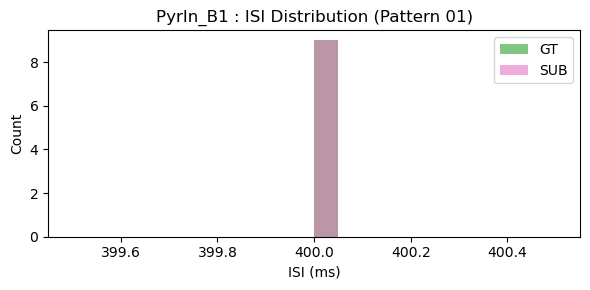


Neuron: PyrIn_A | Pattern: 11
  GT  - CV: 0.4708 | Fano: 0.0
  SUB - CV: 0.4708 | Fano: 0.0
  Wasserstein: 0.0000


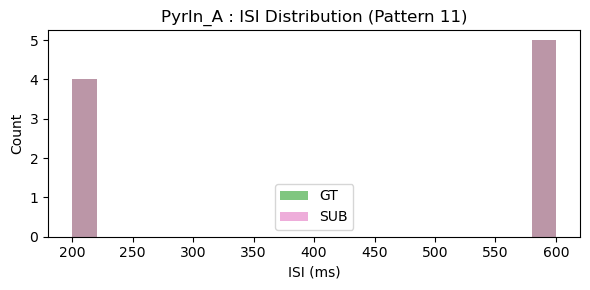


Neuron: PyrIn_A | Pattern: 10
  GT  - CV: 0.5261 | Fano: 0.0
  SUB - CV: 0.5261 | Fano: 0.0
  Wasserstein: 0.0000


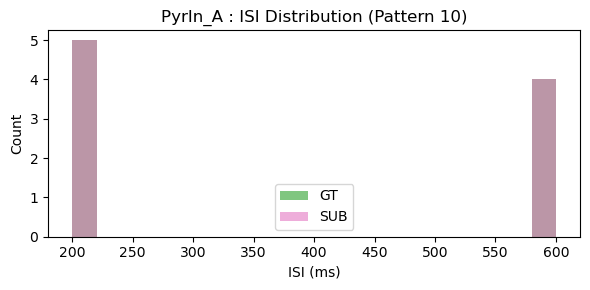


Neuron: PyrIn_B2 | Pattern: 11
  GT  - CV: 0.4708 | Fano: 0.0
  SUB - CV: 0.4708 | Fano: 0.0
  Wasserstein: 0.0000


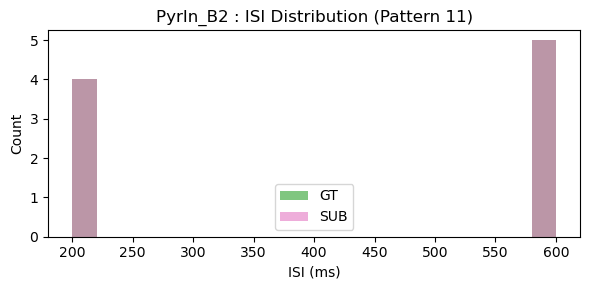


Neuron: PyrIn_B2 | Pattern: 01
  GT  - CV: 0.0000 | Fano: 0.0
  SUB - CV: 0.0000 | Fano: 0.0
  Wasserstein: 0.0000


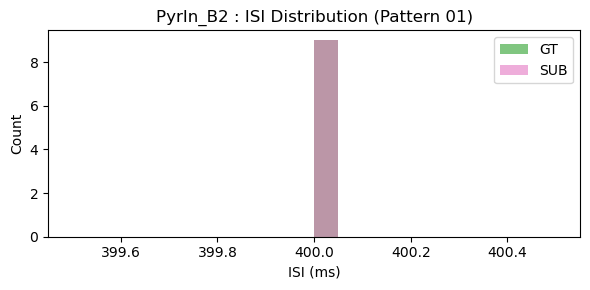

In [22]:
#ISI

try:
    from scipy.stats import wasserstein_distance
except Exception:
    wasserstein_distance = None

rows = []


def compute_isi_metrics(data_spikes,data, cfg, patterns, tmap):
    rows = []
    for neuron in get_spiking_neurons(cfg, data):
        for p in patterns:
            spike_times = data_spikes[
                (data_spikes["label"] == neuron) & 
                (data_spikes["pattern"] == p)
            ]["spike_time_ms"].to_numpy()
            
            all_reps = tmap[tmap["case"] == p]["rep"].unique()
            counts = data_spikes[
                (data_spikes["label"] == neuron) & 
                (data_spikes["pattern"] == p)
            ].groupby("rep").size().reindex(all_reps, fill_value=0).to_numpy()
            
            isi = np.diff(spike_times)
            
            cv   = np.std(isi) / np.mean(isi) if len(isi) > 0 else None
            fano = np.var(counts) / np.mean(counts) if np.mean(counts) > 0 else None
            
            rows.append({
                "neuron":  neuron,
                "pattern": p,
                "cv":      cv,
                "fano":    fano,
                "isi":     isi  # keep raw ISI for wasserstein + plotting later
            })
    return pd.DataFrame(rows)

gt_isi_stats = compute_isi_metrics(gt_spikes,gt_data,cfg,patterns, tmap)
sub_isi_stats = compute_isi_metrics(gt_spikes,sub_data,cfg,patterns, tmap)
print("GT Model")
print()
print(gt_isi_stats.to_string())
print()
print("SUB Model")
print()
print(sub_isi_stats.to_string())


def plot_isi(gt_isi_df, sub_isi_df):
    for neuron in gt_isi_df["neuron"].unique():
        for p in patterns:
            gt_row = gt_isi_df[(gt_isi_df["neuron"] == neuron) & (gt_isi_df["pattern"] == p)]
            sub_row = sub_isi_df[(sub_isi_df["neuron"] == neuron) & (sub_isi_df["pattern"] == p)]
            
            gt_isi = gt_row["isi"].values[0]
            sub_isi = sub_row["isi"].values[0]
            
            if len(gt_isi) == 0 and len(sub_isi) == 0:
                continue  #Skip that dont give results
            
            if len(gt_isi) > 0 and len(sub_isi) > 0:
                w = wasserstein_distance(gt_isi, sub_isi)
            else:
                w = None

            # print the data
            print(f"\nNeuron: {neuron} | Pattern: {p}")
            print(f"  GT  - CV: {gt_row['cv'].values[0]:.4f} | Fano: {gt_row['fano'].values[0]}")
            print(f"  SUB - CV: {sub_row['cv'].values[0]:.4f} | Fano: {sub_row['fano'].values[0]}")
            print(f"  Wasserstein: {w:.4f}" if w is not None else "  Wasserstein: N/A")
            # plot
            fig, ax = plt.subplots(figsize=(6, 3))
            if len(gt_isi) > 0:
                ax.hist(gt_isi, bins=20, alpha=0.6, label="GT", color="tab:green")
            if len(sub_isi) > 0:
                ax.hist(sub_isi, bins=20, alpha=0.6, label="SUB", color="tab:pink")
            
            ax.set_title(f"{neuron} : ISI Distribution (Pattern {p})")
            ax.set_xlabel("ISI (ms)")
            ax.set_ylabel("Count")
            ax.legend()
            plt.tight_layout()
            plt.show()


plot_isi(gt_isi_stats,sub_isi_stats)

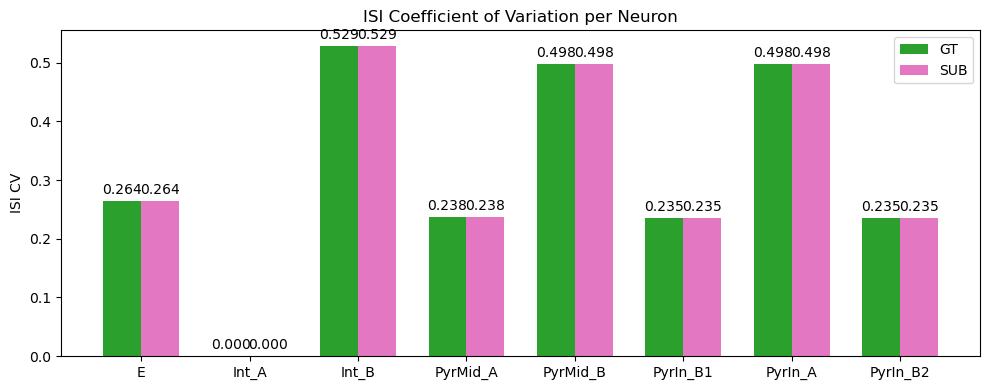

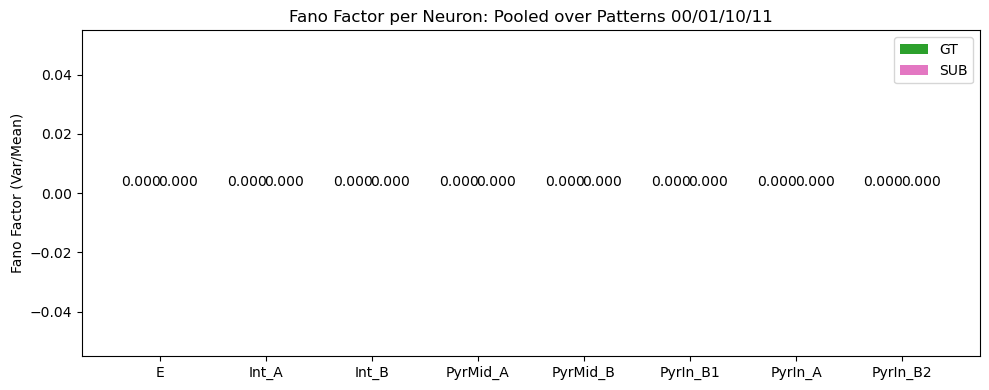

In [21]:
#Summary PLots for ISI and Fano Factor

def plot_isi_cv_summary(gt_isi_df, sub_isi_df):
    neurons = gt_isi_df["neuron"].unique()
    
    gt_cv  = [gt_isi_df[gt_isi_df["neuron"] == n]["cv"].dropna().mean() for n in neurons]
    sub_cv = [sub_isi_df[sub_isi_df["neuron"] == n]["cv"].dropna().mean() for n in neurons]
    
    x = np.arange(len(neurons))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 4))
    bars_gt  = ax.bar(x - width/2, gt_cv,  width, label="GT",  color="tab:green")
    bars_sub = ax.bar(x + width/2, sub_cv, width, label="SUB", color="tab:pink")
    
    ax.bar_label(bars_gt,  fmt="%.3f", padding=3)
    ax.bar_label(bars_sub, fmt="%.3f", padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels(neurons)
    ax.set_ylabel("ISI CV")
    ax.set_title("ISI Coefficient of Variation per Neuron")
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_fano_summary(gt_isi_df, sub_isi_df):
    neurons = gt_isi_df["neuron"].unique()
    
    gt_fano  = [gt_isi_df[gt_isi_df["neuron"] == n]["fano"].dropna().mean() for n in neurons]
    sub_fano = [sub_isi_df[sub_isi_df["neuron"] == n]["fano"].dropna().mean() for n in neurons]
    
    x = np.arange(len(neurons))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 4))
    bars_gt  = ax.bar(x - width/2, gt_fano,  width, label="GT",  color="tab:green")
    bars_sub = ax.bar(x + width/2, sub_fano, width, label="SUB", color="tab:pink")
    
    ax.bar_label(bars_gt,  fmt="%.3f", padding=3)
    ax.bar_label(bars_sub, fmt="%.3f", padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels(neurons)
    ax.set_ylabel("Fano Factor (Var/Mean)")
    ax.set_title("Fano Factor per Neuron: Pooled over Patterns 00/01/10/11")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_isi_cv_summary(gt_isi_stats,sub_isi_stats)
plot_fano_summary(gt_isi_stats,sub_isi_stats)

In [ ]:
# Raster 